In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Construct Brillouin Zone

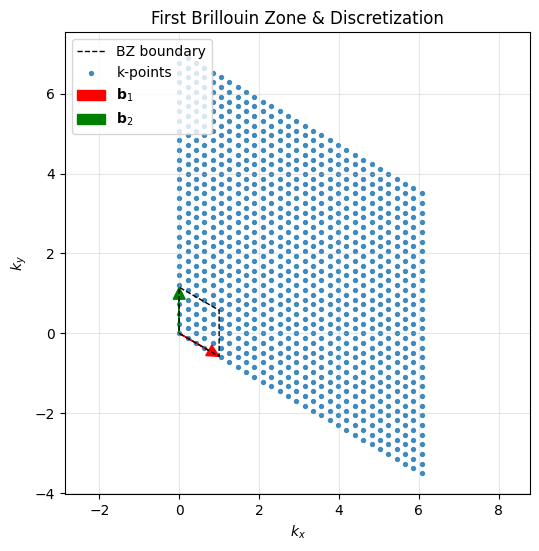

In [23]:
a = 1 # Lattice constant
L1, L2 = 30, 30  # You can adjust these for denser/sparser sampling

# Define reciprocal lattice vectors
a1,a2 = a* np.array([1,0]),a* np.array([np.cos(np.pi/3),np.sin(np.pi/3)])
b1 = 2 / (np.sqrt(3) * a) * np.array([np.cos(np.pi / 6), -np.sin(np.pi / 6)])
b2 = 2 / (np.sqrt(3) * a) * np.array([0,1])
# Generate k-points in the 1st Brillouin Zone parallelogram
k_pts = []
for i in range(L1):
    for j in range(L2):
        k = (2*np.pi * i / L1) * b1 + (2*np.pi * j / L2) * b2
        k_pts.append(k)
k_pts = np.array(k_pts)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

# Plot the parallelogram (BZ) edges
corner = np.array([[0, 0], b1, b1 + b2, b2, [0, 0]])
ax.plot(corner[:, 0], corner[:, 1], 'k--', linewidth=1, label='BZ boundary')

# Plot lattice points in the BZ
ax.scatter(k_pts[:, 0], k_pts[:, 1], s=8, color='C0', alpha=0.8, label='k-points')

# Plot reciprocal lattice vectors
ax.arrow(0, 0, b1[0], b1[1], head_width=0.3, head_length=0.3, fc='r', ec='r', length_includes_head=True, label=r'$\mathbf{b}_1$')
ax.arrow(0, 0, b2[0], b2[1], head_width=0.3, head_length=0.3, fc='g', ec='g', length_includes_head=True, label=r'$\mathbf{b}_2$')

# Formatting
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_title('First Brillouin Zone & Discretization')
ax.axis('equal')
ax.legend(['BZ boundary', 'k-points', r'$\mathbf{b}_1$', r'$\mathbf{b}_2$'], loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# Step 2: Compute Matrices $D_k$ from Parameters

In [ ]:

from numpy._typing._array_like import NDArray


from typing import Any


theta_a,phi_a = np.arccos(-np.sqrt(2/3)),np.pi/4
theta_nega,phi_nega = np.arccos(np.sqrt(2/3)),5 *np.pi/4
hRatio = 0.2
K, Gamma, GammaPrime = -1,0.2,-0.02

# Takes (0,0,1), and maps to a vector with \phi (polar in xy) and \theta (azimuth) spherical coordinates.
def Rot(theta,phi):
    return np.array([[np.cos(theta)*np.cos(phi), - np.sin(phi), np.sin(theta)*np.cos(phi)],
                     [np.cos(theta)*np.sin(phi), np.cos(phi), np.sin(theta)*np.sin(phi)],
                     [-np.sin(theta), 0, np.cos(theta)]])




def Hmats(K,Gamma,GammaPrime):    
    H_x = np.array([[K,GammaPrime,GammaPrime],
                    [GammaPrime,0,Gamma],
                    [GammaPrime,Gamma,0]])
    H_y = np.array([[0,GammaPrime,Gamma],
                    [GammaPrime,K,GammaPrime],
                    [Gamma,GammaPrime,0]])
    H_z = np.array([[0,Gamma,GammaPrime],
                    [Gamma,0,GammaPrime],
                    [GammaPrime,GammaPrime,K]])
    return H_x,H_y,H_z

def HTildeMats(K,Gamma,GammaPrime,theta,phi):

    H_x,H_y,H_z = Hmats(K,Gamma,GammaPrime)
    R = Rot(theta,phi)
    Htilde_x = R.T @ H_x @ R
    Htilde_y = R.T @ H_y @ R
    Htilde_z = R.T @ H_z @ R
    return Htilde_x,Htilde_y,Htilde_z

def deltaLambdas(a1,a2):
    delta_x = -a1 + 0*a2
    delta_y = a1 - a2
    delta_z = 0*a1 + 0*a2
    return delta_x,delta_y,delta_z

def getDk(K,Gamma,GammaPrime,theta,phi,a1,a2):
    h = hRatio * 1/2 * np.abs(K)

    Htildes = HTildeMats(K,Gamma,GammaPrime,theta,phi)
    deltas = deltaLambdas(a1,a2)
    zipped_iterable =  zip[tuple[NDArray[Any], Any]](Htildes, deltas)

    # k is a (x,y) vector in reciprocal space
    def Dk(k):
        # Construct A_k and B_k
        A_k = np.array([[h,0],[0,h]])
        B_k = np.array([[0,0],[0,0]])

        for Htilde, delta in zipped_iterable:
            h11,h22,h33,h12 = Htilde[0,0],Htilde[1,1],Htilde[2,2], Htilde[0,1]
            exponent_pos = np.exp(1j * k * delta)
            exponent_neg = np.exp(-1j * k * delta)

            





    for htilde in [Htilde_x,Htilde_y,Htilde_z]:
        h11,h22,h33 = htilde[0,0],htilde[1,1],htilde[2,2]

        exponent = np.exp(1j * k * )

        next_term_A_k = np.array([[-h33,],[]])





computeDk(K,Gamma,GammaPrime,theta_a,phi_a)

[[0.1 0. ]
 [0.  0.1]]


In [ ]:
a_vec = (Rot(theta_a,phi_a) @ np.array([0,0,1]))
a_vec /= np.abs(a_vec[0])
# print(a_vec) # Should be (1,1,-2)

nega_vec = (Rot(theta_nega,phi_nega) @ np.array([0,0,1]))
nega_vec /= np.abs(nega_vec[0])
# print(nega_vec)  # Should be (-1,-1,2)

# Step 3: Compute Dispersion

# Step 4: Compute Berry Curvature

# Step 5: Compute Hall Conductivity (Sum Berry Curvature over BZ)